In [1]:
!pip install -q open-clip-torch tqdm

import sys
from pathlib import Path

try:
    from google.colab import drive
    drive.mount('/content/drive')
    DRIVE_ROOT = '/content/drive/MyDrive/liya_diploma'
    AI_TOOLKIT = '/content/ai-toolkit'
except ModuleNotFoundError:
    _here = Path().resolve()
    DRIVE_ROOT = str(_here if (_here / 'scripts').exists() else _here.parent)
    AI_TOOLKIT = str(Path(DRIVE_ROOT).parent / 'ai-toolkit')

for p in (DRIVE_ROOT, AI_TOOLKIT):
    if p not in sys.path:
        sys.path.insert(0, p)
print(f"DRIVE_ROOT: {DRIVE_ROOT}")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 13.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 1.2 MB/s eta 0:00:00
Mounted at /content/drive
DRIVE_ROOT: /content/drive/MyDrive/liya_diploma


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:103: UserWarning: 
Error while fetching `HF_TOKEN` secret value from your vault: 'Requesting secret HF_TOKEN timed out. Secrets can only be fetched when running from the Colab UI.'.
You are not authenticated with the Hugging Face Hub in this notebook.
If the error persists, please let us know by opening an issue on GitHub (https://github.com/huggingface/huggingface_hub/issues/new).
  warnings.warn(


open_clip_model.safetensors:   0%|          | 0.00/605M [00:00<?, ?B/s]

/usr/local/lib/python3.12/dist-packages/open_clip/factory.py:450: UserWarning: QuickGELU mismatch between final model config (quick_gelu=False) and pretrained tag 'openai' (quick_gelu=True).
  warnings.warn(
CLIP scoring: 100%|██████████| 200/200 [02:43<00:00,  1.22it/s]


CLIP Score — mean=0.325, min=0.195, max=0.448
Pairs above 0.25: 189/200


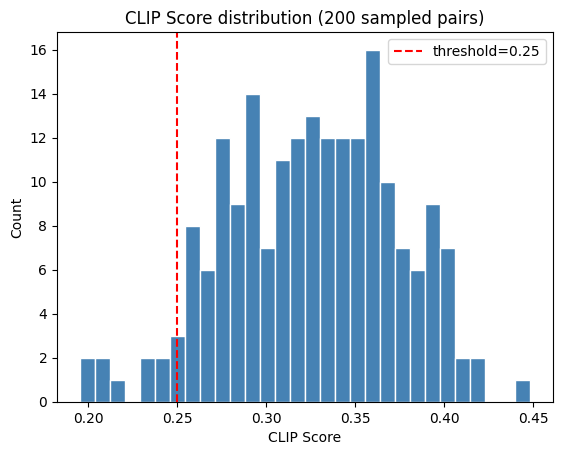

In [2]:
import matplotlib.pyplot as plt
import numpy as np

from scripts.verify_dataset import compute_clip_scores

scores = compute_clip_scores(
    f'{DRIVE_ROOT}/data/captioned_pairs.jsonl',
    sample_size=200,
    seed=42,
)
print(f"CLIP Score — mean={np.mean(scores):.3f}, "
      f"min={np.min(scores):.3f}, max={np.max(scores):.3f}")
print(f"Pairs above 0.25: {sum(s >= 0.25 for s in scores)}/200")

plt.hist(scores, bins=30, color='steelblue', edgecolor='white')
plt.axvline(0.25, color='red', linestyle='--', label='threshold=0.25')
plt.xlabel("CLIP Score")
plt.ylabel("Count")
plt.title("CLIP Score distribution (200 sampled pairs)")
plt.legend()
plt.savefig(f'{DRIVE_ROOT}/results/metrics/clip_score_distribution.png', dpi=150)
plt.show()


In [3]:
import json
import random

TEST_SIZE = 500

random.seed(42)
with open(f'{DRIVE_ROOT}/data/captioned_pairs.jsonl') as f:
    all_pairs = [json.loads(l) for l in f]
random.shuffle(all_pairs)

if len(all_pairs) <= TEST_SIZE:
    raise RuntimeError(
        f"Only {len(all_pairs)} pairs available — нужно больше {TEST_SIZE}, "
        f"иначе на train ничего не останется. Добавь датасеты в ноутбук 01."
    )

test  = all_pairs[:TEST_SIZE]
train = all_pairs[TEST_SIZE:]
print(f"Total: {len(all_pairs)} pairs -> test={len(test)}, train={len(train)}")


def save_split(pairs, path, split_name):
    with open(path, 'w', encoding='utf-8') as f:
        for item in pairs:
            f.write(json.dumps({**item, 'split': split_name}) + '\n')
    print(f"Saved {len(pairs)} pairs -> {path}")


save_split(test,  f'{DRIVE_ROOT}/data/test_500.jsonl', 'test')
save_split(train, f'{DRIVE_ROOT}/data/train.jsonl',    'train')


Total: 10000 pairs -> test=500, train=9500
Saved 500 pairs -> /content/drive/MyDrive/liya_diploma/data/test_500.jsonl
Saved 9500 pairs -> /content/drive/MyDrive/liya_diploma/data/train.jsonl


In [4]:
import json


def _load_paths(path):
    with open(path, encoding='utf-8') as f:
        return {json.loads(l)['png_path'] for l in f}


for name, path in [
    ('test_500', f'{DRIVE_ROOT}/data/test_500.jsonl'),
    ('train',    f'{DRIVE_ROOT}/data/train.jsonl'),
]:
    with open(path, encoding='utf-8') as f:
        n = sum(1 for _ in f)
    print(f"{name}: {n} pairs")

test_paths  = _load_paths(f'{DRIVE_ROOT}/data/test_500.jsonl')
train_paths = _load_paths(f'{DRIVE_ROOT}/data/train.jsonl')

assert not (test_paths & train_paths), "OVERLAP: test_500 и train пересекаются!"
print(f"PASS: test_500 ({len(test_paths)}) и train ({len(train_paths)}) не пересекаются")


test_500: 500 pairs
train: 9500 pairs
PASS: test_500 (500) и train (9500) не пересекаются
